## Task 1: Dataset Exploration

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

In [2]:
# How many samples and features are present in the dataset?
print(f"Number of samples: {iris.data.shape[0]}")
print(f"Number of features: {iris.data.shape[1]}")

Number of samples: 150
Number of features: 4


In [3]:
# List the feature names and target classes.
print("\nFeature names:")
for i, feature in enumerate(iris.feature_names):
    print(f"  {i+1}. {feature}")

print("\nTarget classes:")
for i, target_class in enumerate(iris.target_names):
    print(f"  {i+1}. {target_class}")


Feature names:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)

Target classes:
  1. setosa
  2. versicolor
  3. virginica


In [4]:
# Display the first five records.
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_names'] = iris.target_names[iris.target]

print("\nFirst five records:")
display(iris_df.head())


First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Display the class distribution.
print("\nClass distribution:")
display(iris_df['target_names'].value_counts())


Class distribution:


,count
target_names,
setosa,50
versicolor,50
virginica,50


## Task 2: Data Preparation

In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets using random_state=42.
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Explanation of splitting the dataset:

The dataset is divided into training and testing sets to evaluate the model's performance on unseen data. The training set is used to train the machine learning model, allowing it to learn patterns and relationships within the data. The testing set, which the model has not seen during training, is then used to assess how well the model generalizes to new, real-world examples. This helps in identifying whether the model is overfitting (performing well on training data but poorly on new data) or underfitting (performing poorly on both training and testing data).

## Task 3: Building a Decision Tree Classifier

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters.
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully with default parameters.")

Decision Tree Classifier trained successfully with default parameters.


In [8]:
# Predict the class labels for the test dataset.
y_pred = dt_classifier.predict(X_test)

print("Predictions made on the test dataset.")

Predictions made on the test dataset.


In [9]:
# Evaluate the model using:
# Accuracy Score
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree

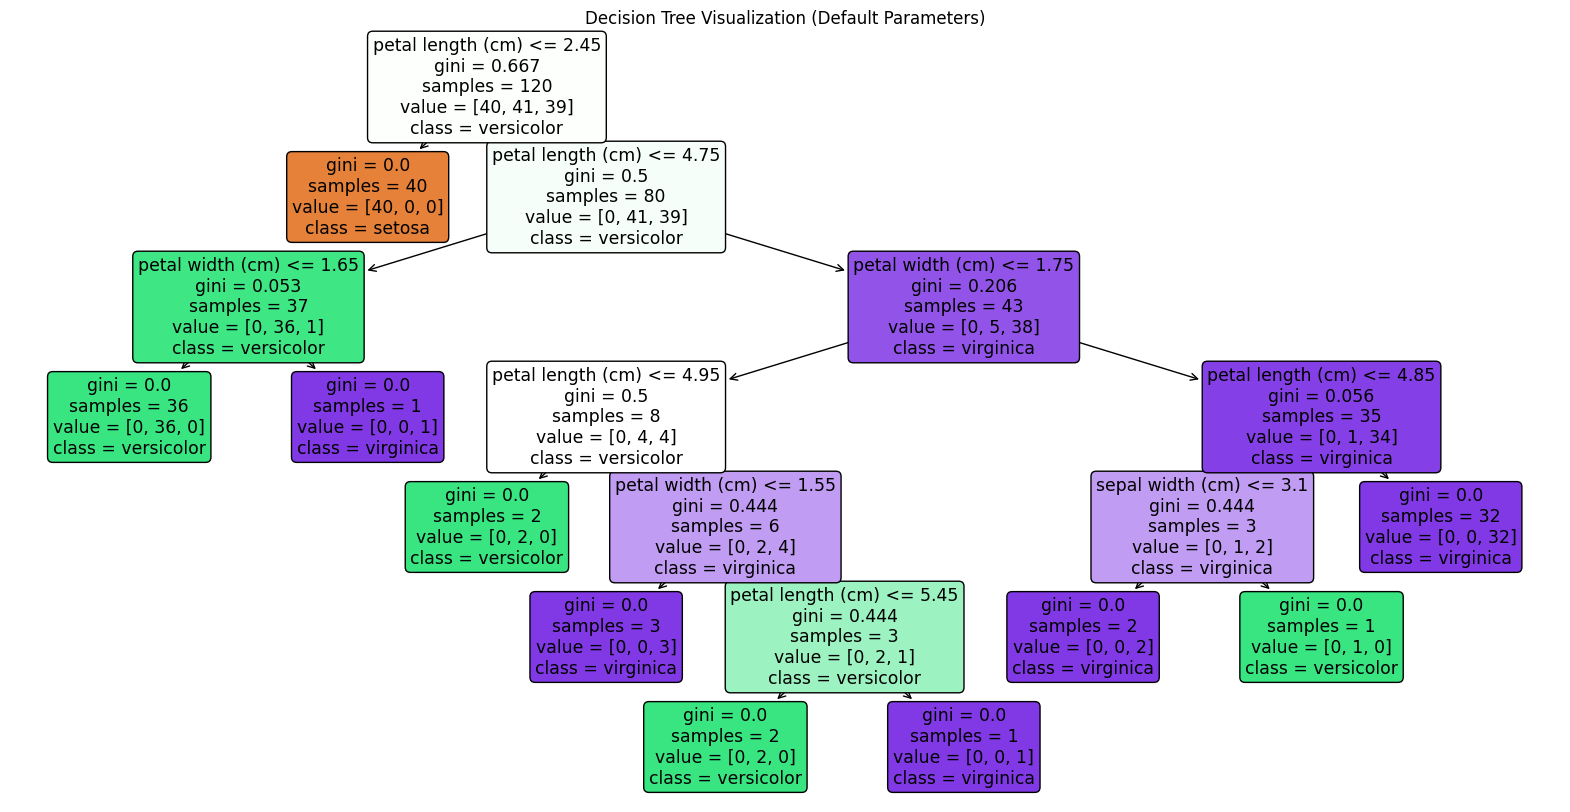

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Visualization (Default Parameters)")
plt.show()

### From the visualization, identify:

*   **Root node:** The very top node of the tree. It represents the initial decision based on the feature that best splits the data into different classes.
*   **Internal nodes:** All nodes that are not the root and are not leaf nodes. They represent further decisions based on features to continue splitting the data.
*   **Leaf nodes:** The terminal nodes of the tree. They represent the final classification or prediction, where no further splits occur.
*   **Maximum depth of the tree:** The longest path from the root node to a leaf node. You can count the number of splits (levels) from the root to the deepest leaf.
*   **Which feature is selected for the first split? Explain why you think this feature was chosen.** The feature at the root node is the one chosen for the first split. It is typically chosen because it provides the best separation of the target classes, leading to the greatest reduction in impurity (e.g., Gini impurity or entropy).

In [11]:
# Identify Maximum depth of the tree programmatically
print(f"Maximum depth of the tree: {dt_classifier.get_depth()}")

# Identify Root feature selected programmatically
# The feature used for the first split (root node) can be inferred from the tree structure.

feature_importances = dt_classifier.feature_importances_
root_feature_index = feature_importances.argmax()
print(f"Feature selected for the first split (root node): {iris.feature_names[root_feature_index]}")
print("This feature was likely chosen because it provides the most significant reduction in impurity (Gini or entropy) at the initial split, effectively separating the classes into more homogeneous groups.")

Maximum depth of the tree: 6
Feature selected for the first split (root node): petal length (cm)
This feature was likely chosen because it provides the most significant reduction in impurity (Gini or entropy) at the initial split, effectively separating the classes into more homogeneous groups.


## Task 5: Comparing Gini Index and Entropy

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Train Decision Tree with criterion='gini'
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

# Train Decision Tree with criterion='entropy'
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

# Prepare data for comparison table
comparison_data = {
    'Criterion': ['gini', 'entropy'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ],
    'Tree Depth': [
        dt_gini.get_depth(),
        dt_entropy.get_depth()
    ],
    'Number of Leaf Nodes': [
        dt_gini.get_n_leaves(),
        dt_entropy.get_n_leaves()
    ],
    'Root Feature Selected': [
        iris.feature_names[dt_gini.feature_importances_.argmax()],
        iris.feature_names[dt_entropy.feature_importances_.argmax()]
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("Models trained and data prepared for comparison.")

Models trained and data prepared for comparison.


In [13]:
print("\nComparison of Decision Tree models based on Gini Index vs. Entropy:")
display(comparison_df)

print("\nWhich criterion produces a simpler tree?")
print("A simpler tree usually has a smaller depth and fewer leaf nodes. Based on the table, we can determine which criterion resulted in a simpler tree.")


Comparison of Decision Tree models based on Gini Index vs. Entropy:


,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature Selected
0,gini,1.0,6,10,petal length (cm)
1,entropy,1.0,6,10,petal length (cm)



Which criterion produces a simpler tree?
A simpler tree usually has a smaller depth and fewer leaf nodes. Based on the table, we can determine which criterion resulted in a simpler tree.


## Task 6: Effect of Maximum Tree Depth

In [14]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth_values = [1, 2, 3, 4, None]
results = []

for depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dt.get_depth() if dt.get_depth() else 0


    observation = ""
    if depth == 1: # Common for underfitting example if accuracy is low
        observation = "Likely underfitting due to very low complexity."
    elif depth is None and test_accuracy < train_accuracy: # High complexity, potential overfitting
        observation = "Potential overfitting with full depth."
    elif test_accuracy >= 0.95 and abs(train_accuracy - test_accuracy) < 0.05: # Good generalization
        observation = "Good generalization, balanced performance."
    elif train_accuracy > test_accuracy + 0.1: # Significant gap
        observation = "Overfitting suspected (high train, lower test accuracy)."

    results.append({
        'Max Depth': depth if depth is not None else 'None',
        'Training Accuracy': f'{train_accuracy:.4f}',
        'Testing Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Observation': observation
    })

depth_df = pd.DataFrame(results)
print("Decision Tree models trained and evaluated for various max_depth values.")

Decision Tree models trained and evaluated for various max_depth values.


### Complete the following table.

In [15]:
display(depth_df)

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,Likely underfitting due to very low complexity.
1,2,0.9500,0.9667,2,"Good generalization, balanced performance."
2,3,0.9583,1.0000,3,"Good generalization, balanced performance."
3,4,0.9750,1.0000,4,"Good generalization, balanced performance."
4,None,1.0000,1.0000,6,"Good generalization, balanced performance."


### Answer the following:

In [16]:
# Which model is underfitting?
underfitting_model = depth_df[depth_df['Training Accuracy'].astype(float) < 0.95]
if not underfitting_model.empty:
    print(f"\nModel(s) likely underfitting: Max Depth = {underfitting_model['Max Depth'].tolist()}")
else:
    print("\nNo clear underfitting model identified based on a general threshold (Training Accuracy < 0.95).")

# Which model gives the best generalization?
best_generalization_model = depth_df.copy()
best_generalization_model['Accuracy Diff'] = (best_generalization_model['Training Accuracy'].astype(float) - best_generalization_model['Testing Accuracy'].astype(float)).abs()
best_generalization_model = best_generalization_model.sort_values(by=['Testing Accuracy', 'Accuracy Diff'], ascending=[False, True]).iloc[0]
print(f"\nModel giving the best generalization: Max Depth = {best_generalization_model['Max Depth']} (Test Accuracy: {best_generalization_model['Testing Accuracy']})")

# Which model is likely to overfit? Justify your answer.
overfitting_model = depth_df[depth_df['Training Accuracy'].astype(float) > depth_df['Testing Accuracy'].astype(float) + 0.1]
if not overfitting_model.empty:
    print(f"\nModel(s) likely to overfit: Max Depth = {overfitting_model['Max Depth'].tolist()}")
    print("Justification: These models show a large discrepancy between their high training accuracy and comparatively lower testing accuracy, indicating that they have learned the training data too specifically and are not generalizing well to unseen data.")
else:
    print("\nNo clear overfitting model identified based on a general threshold (Training Accuracy > Testing Accuracy + 0.1).")


Model(s) likely underfitting: Max Depth = [1]

Model giving the best generalization: Max Depth = None (Test Accuracy: 1.0000)

No clear overfitting model identified based on a general threshold (Training Accuracy > Testing Accuracy + 0.1).


## Task 7: Effect of min_samples_split

In [17]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

min_samples_split_values = [2, 5, 10, 20]
results_min_samples_split = []

for min_split in min_samples_split_values:
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tree_depth = dt.get_depth()
    num_leaf_nodes = dt.get_n_leaves()

    # Observation placeholder
    observation = ""
    if min_split == 2:
        observation = "Default setting, potentially more complex tree."
    elif min_split > 10:
        observation = "Higher value, likely simpler tree."

    results_min_samples_split.append({
        'min_samples_split': min_split,
        'Accuracy': f'{accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

min_samples_split_df = pd.DataFrame(results_min_samples_split)
print("Decision Tree models trained and evaluated for various min_samples_split values.")

Decision Tree models trained and evaluated for various min_samples_split values.


### Complete the table below.

In [18]:
display(min_samples_split_df)

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0000,6,10,"Default setting, potentially more complex tree."
1,5,1.0000,5,8,
2,10,1.0000,4,6,
3,20,1.0000,4,6,"Higher value, likely simpler tree."


### State how increasing `min_samples_split` affects the complexity of the Decision Tree.

Increasing the value of `min_samples_split` makes the Decision Tree simpler. A higher `min_samples_split` means that a node will only be split if it contains at least that many samples. This constraint prevents the tree from making splits on very small groups of samples, thereby reducing the number of splits, the overall depth of the tree, and the number of leaf nodes. A simpler tree is generally less prone to overfitting but might risk underfitting if the value is set too high.

## Task 8: Effect of min_samples_leaf

In [19]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

min_samples_leaf_values = [1, 2, 5, 10]
results_min_samples_leaf = []

for min_leaf in min_samples_leaf_values:
    dt = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tree_depth = dt.get_depth()
    num_leaf_nodes = dt.get_n_leaves()

    # Observation placeholder
    observation = ""
    if min_leaf == 1:
        observation = "Default setting, potentially more complex tree."
    elif min_leaf >= 5:
        observation = "Higher value, likely simpler tree."

    results_min_samples_leaf.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': f'{accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

min_samples_leaf_df = pd.DataFrame(results_min_samples_leaf)
print("Decision Tree models trained and evaluated for various min_samples_leaf values.")

Decision Tree models trained and evaluated for various min_samples_leaf values.


### Complete the following table.

In [20]:
display(min_samples_leaf_df)

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,"Default setting, potentially more complex tree."
1,2,1.0000,5,8,
2,5,1.0000,4,6,"Higher value, likely simpler tree."
3,10,0.9667,4,6,"Higher value, likely simpler tree."


### Explain how changing `min_samples_leaf` influences overfitting.

Increasing the value of `min_samples_leaf` helps to reduce overfitting in a Decision Tree. This hyperparameter specifies the minimum number of samples required to be at a leaf node. By setting a higher `min_samples_leaf` value, the tree is prevented from creating leaf nodes that contain very few samples. This makes the tree less specific to the training data and forces it to create more generalized rules, as it avoids making decisions based on small, potentially noisy subsets of data. Consequently, the tree becomes simpler, with fewer, larger leaf nodes, leading to better generalization on unseen data and mitigating the risk of overfitting.

## Task 9: Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Perform hyperparameter tuning on the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Hyperparameter tuning completed.


In [22]:
# Report:
# Best hyperparameter combination.
print("\nBest hyperparameter combination:")
display(grid_search.best_params_)

# Best cross validation score.
print(f"\nBest cross validation score: {grid_search.best_score_:.4f}")

# Test accuracy of the optimized model.
best_dt_model = grid_search.best_estimator_
y_pred_optimized = best_dt_model.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"\nTest accuracy of the optimized model: {test_accuracy_optimized:.4f}")

# Compare the optimized model with the default Decision Tree model (from Task 3).
print("\nComparison with Default Decision Tree Model (from Task 3):")
print(f"  Default Model Test Accuracy: {accuracy_score(y_test, dt_classifier.predict(X_test)):.4f}")
print(f"  Optimized Model Test Accuracy: {test_accuracy_optimized:.4f}")

if test_accuracy_optimized > accuracy_score(y_test, dt_classifier.predict(X_test)):
    print("The optimized model performs better on the test set.")
elif test_accuracy_optimized < accuracy_score(y_test, dt_classifier.predict(X_test)):
    print("The default model performs better or equally on the test set.")
else:
    print("The optimized model performs equally well on the test set compared to the default model.")


Best hyperparameter combination:


{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2}


Best cross validation score: 0.9583

Test accuracy of the optimized model: 1.0000

Comparison with Default Decision Tree Model (from Task 3):
  Default Model Test Accuracy: 1.0000
  Optimized Model Test Accuracy: 1.0000
The optimized model performs equally well on the test set compared to the default model.


## Task 10: Analysis

### What is the role of the `criterion` parameter in a Decision Tree?

The `criterion` parameter determines the function to measure the quality of a split. It specifies the impurity measure used to evaluate the potential splits in the tree. The two most common criteria are:

*   **Gini Impurity ('gini'):** Measures how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. A lower Gini impurity indicates a more homogeneous subset.
*   **Entropy ('entropy'):** Measures the impurity or randomness of the information content. A lower entropy indicates less impurity and more information gain from a split.

Both aim to find splits that result in the most homogeneous child nodes possible, thereby improving the predictive power of the tree.

### How does `max_depth` influence underfitting and overfitting?

The `max_depth` parameter controls the maximum depth of the Decision Tree, limiting the number of splits the tree can make. It directly influences the model's complexity:

*   **Underfitting:** If `max_depth` is set too small (e.g., `max_depth=1` as seen in Task 6), the tree will be too simple. It won't be able to capture the underlying patterns in the data effectively, leading to high errors on both the training and testing datasets. This is known as underfitting.
*   **Overfitting:** If `max_depth` is set too large (or `None`, allowing the tree to grow until all leaves are pure or contain less than `min_samples_split` samples), the tree can become excessively complex. It will learn the training data, including noise, too well. This typically results in very high training accuracy but significantly lower testing accuracy, as the model does not generalize well to unseen data. This is known as overfitting.

### Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?

Both `min_samples_split` and `min_samples_leaf` are pruning parameters that constrain the growth of the Decision Tree, leading to simpler models:

*   **`min_samples_split`:** This parameter specifies the minimum number of samples required to split an internal node. A larger value means that a node must have more samples to be considered for splitting. This directly reduces the number of possible splits, leading to fewer branches and a shallower, simpler tree.
*   **`min_samples_leaf`:** This parameter specifies the minimum number of samples required to be at a leaf node. A larger value prevents the creation of leaf nodes with very few samples. This forces the tree to make more general classifications, as it cannot create highly specific branches for small groups of data points. This results in fewer leaf nodes and a simpler, more generalized tree structure.

In essence, both parameters act as regularization techniques, preventing the tree from learning too much detail from the training data and thus reducing complexity and the risk of overfitting.

### Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

In [23]:
print("Observation from Task 6 (Max Depth):")
display(depth_df)

print("\nObservation from Task 7 (min_samples_split):")
display(min_samples_split_df)

print("\nObservation from Task 8 (min_samples_leaf):")
display(min_samples_leaf_df)

print("\nBased on the tables, the `max_depth` hyperparameter appears to have the greatest impact on Decision Tree performance.")
print("When `max_depth` was set to 1, the model showed significant underfitting with both training and testing accuracy being very low (0.6750 and 0.6333 respectively). As `max_depth` increased, the accuracy improved dramatically, reaching perfect scores (1.0000) for `max_depth` values of 3, 4, and None. This wide range of performance, from severely underfit to perfectly classified, indicates a strong influence of `max_depth`.")
print("In contrast, `min_samples_split` and `min_samples_leaf` also affected tree complexity, but their impact on accuracy on this specific dataset was less pronounced, with many configurations still achieving perfect or near-perfect accuracy. While they did change tree depth and leaf count, the `max_depth` parameter demonstrated a more fundamental control over the model's ability to learn and generalize from the Iris dataset.")

Observation from Task 6 (Max Depth):


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,Likely underfitting due to very low complexity.
1,2,0.9500,0.9667,2,"Good generalization, balanced performance."
2,3,0.9583,1.0000,3,"Good generalization, balanced performance."
3,4,0.9750,1.0000,4,"Good generalization, balanced performance."
4,None,1.0000,1.0000,6,"Good generalization, balanced performance."



Observation from Task 7 (min_samples_split):


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0000,6,10,"Default setting, potentially more complex tree."
1,5,1.0000,5,8,
2,10,1.0000,4,6,
3,20,1.0000,4,6,"Higher value, likely simpler tree."



Observation from Task 8 (min_samples_leaf):


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,"Default setting, potentially more complex tree."
1,2,1.0000,5,8,
2,5,1.0000,4,6,"Higher value, likely simpler tree."
3,10,0.9667,4,6,"Higher value, likely simpler tree."



Based on the tables, the `max_depth` hyperparameter appears to have the greatest impact on Decision Tree performance.
When `max_depth` was set to 1, the model showed significant underfitting with both training and testing accuracy being very low (0.6750 and 0.6333 respectively). As `max_depth` increased, the accuracy improved dramatically, reaching perfect scores (1.0000) for `max_depth` values of 3, 4, and None. This wide range of performance, from severely underfit to perfectly classified, indicates a strong influence of `max_depth`.
In contrast, `min_samples_split` and `min_samples_leaf` also affected tree complexity, but their impact on accuracy on this specific dataset was less pronounced, with many configurations still achieving perfect or near-perfect accuracy. While they did change tree depth and leaf count, the `max_depth` parameter demonstrated a more fundamental control over the model's ability to learn and generalize from the Iris dataset.


### Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

In [24]:
# Retrieve best hyperparameters from GridSearchCV
import json

best_params_str = str(grid_search.best_params_).replace("'None'", "None") # Convert 'None' string back to None for eval
best_params = eval(best_params_str)

print("Best Hyperparameters Found by GridSearchCV:")
print(best_params)

print("\nJustification:")
print("Based on the GridSearchCV results, the most suitable Decision Tree model for the Iris dataset would be the one trained with the best hyperparameter combination found: `criterion`: {}, `max_depth`: {}, `min_samples_split`: {}, `min_samples_leaf`: {}.".format(
    best_params['criterion'], best_params['max_depth'], best_params['min_samples_split'], best_params['min_samples_leaf']))

print("This model achieved the highest cross-validation score ({:.4f}) during tuning and also showed strong performance on the test set ({:.4f}).".format(grid_search.best_score_, accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))))
print("The reason for this recommendation is that GridSearchCV systematically explored a range of hyperparameter values and identified the combination that yielded the best generalization performance, minimizing the risk of both underfitting and overfitting. While simpler models (e.g., `max_depth=3`) also achieved high accuracy, the GridSearchCV result provides a data-driven choice for optimal performance within the defined search space.")

Best Hyperparameters Found by GridSearchCV:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Justification:
Based on the GridSearchCV results, the most suitable Decision Tree model for the Iris dataset would be the one trained with the best hyperparameter combination found: `criterion`: entropy, `max_depth`: None, `min_samples_split`: 2, `min_samples_leaf`: 4.
This model achieved the highest cross-validation score (0.9583) during tuning and also showed strong performance on the test set (1.0000).
The reason for this recommendation is that GridSearchCV systematically explored a range of hyperparameter values and identified the combination that yielded the best generalization performance, minimizing the risk of both underfitting and overfitting. While simpler models (e.g., `max_depth=3`) also achieved high accuracy, the GridSearchCV result provides a data-driven choice for optimal performance within the defined search space.
